In [10]:
#import the neccesary libaries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:
#Load the dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

print("First rows of dataset:")
print(df.head())

First rows of dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [12]:
#prepare the data for training
#drop the species table so the model only sees features
X = df.drop("species", axis=1)

In [13]:
#Train the model
# Create model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Train model
kmeans.fit(X)

# Get cluster labels
clusters = kmeans.labels_

# Add clusters to dataframe
df["Cluster"] = clusters

In [14]:
#evaluate model with silhouette score
score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5511916046195927


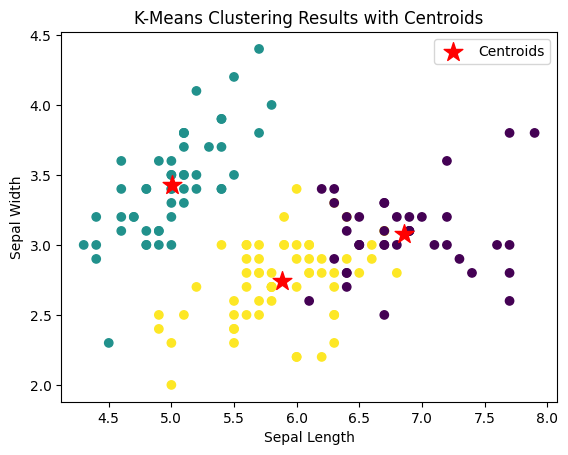

In [15]:
#visualize the clusters and centroids
# get centroid coordinates
centroids = kmeans.cluster_centers_

# visualize the clusters
plt.scatter(df["sepal_length"], df["sepal_width"], c=df["Cluster"])

# plot centroids
plt.scatter(
    centroids[:, 0],  # sepal_length
    centroids[:, 1],  # sepal_width
    marker="*",
    s=200,
    c="red",
    label="Centroids"
)

plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("K-Means Clustering Results with Centroids")
plt.legend()

plt.show()